# XGBoost Model Evaluation

This notebook is the main post-training analysis notebook for the prototype XGBoost model.

It supports:
- fast sampled evaluation by default,
- optional full-split scoring,
- comparison against a naive popularity baseline,
- positive-track-only ranking diagnostics,
- feature importance analysis,
- and lightweight SHAP analysis on a sampled subset when `shap` is installed.


In [10]:
from pathlib import Path
import json
import os
import tempfile
import warnings

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="matplotlib-"))

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from IPython.display import display

try:
    import xgboost as xgb
except ImportError as exc:
    raise ImportError("Install xgboost first, e.g. `pip install -r requirements.txt`.") from exc

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "datasets").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. Expected a parent containing 'datasets/' and 'requirements.txt'."
    )

ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = ROOT / "datasets" / "processed" / "v3_features"
MODEL_DIR = ROOT / "artifacts" / "models" / "xgboost_prototype"
EVAL_DIR = ROOT / "artifacts" / "evaluations" / "xgboost_prototype"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "xgb_classifier.json"
SUMMARY_PATH = MODEL_DIR / "training_summary.json"
VAL_PATH = DATA_DIR / "val.parquet"
TEST_PATH = DATA_DIR / "test.parquet"

assert MODEL_PATH.exists(), f"Missing model artifact: {MODEL_PATH}"
assert SUMMARY_PATH.exists(), f"Missing metadata artifact: {SUMMARY_PATH}"
assert VAL_PATH.exists(), f"Missing validation split: {VAL_PATH}"
assert TEST_PATH.exists(), f"Missing test split: {TEST_PATH}"

TOP_K = 5
VAL_MAX_TRACKS = 10000
TEST_MAX_TRACKS = 10000
RUN_FULL_SPLITS = False
RUN_SHAP = True
SHAP_SAMPLE_TRACKS = 1000

if RUN_FULL_SPLITS:
    VAL_MAX_TRACKS = None
    TEST_MAX_TRACKS = None

RUN_MODE = "full" if RUN_FULL_SPLITS else "sampled"
print({
    "run_mode": RUN_MODE,
    "top_k": TOP_K,
    "val_max_tracks": VAL_MAX_TRACKS,
    "test_max_tracks": TEST_MAX_TRACKS,
    "run_shap": RUN_SHAP,
    "shap_sample_tracks": SHAP_SAMPLE_TRACKS,
})


{'run_mode': 'sampled', 'top_k': 5, 'val_max_tracks': 10000, 'test_max_tracks': 10000, 'run_shap': True, 'shap_sample_tracks': 1000}


In [11]:
con = duckdb.connect()

def load_split(path: Path, max_tracks: int | None = None) -> pd.DataFrame:
    parquet_path = path.as_posix()
    if max_tracks is None:
        query = f"SELECT * FROM read_parquet('{parquet_path}')"
    else:
        query = f"""
            WITH sampled_tracks AS (
                SELECT track_id
                FROM read_parquet('{parquet_path}')
                GROUP BY track_id
                ORDER BY hash(track_id)
                LIMIT {int(max_tracks)}
            )
            SELECT d.*
            FROM read_parquet('{parquet_path}') d
            JOIN sampled_tracks st USING (track_id)
        """
    return con.execute(query).fetchdf()


def binary_metrics(y_true: pd.Series, y_score: np.ndarray) -> dict:
    return {
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "average_precision": float(average_precision_score(y_true, y_score)),
        "log_loss": float(log_loss(y_true, y_score, labels=[0, 1])),
    }


def compute_candidate_stats(scored_df: pd.DataFrame) -> dict:
    per_track = scored_df.groupby("track_id").agg(
        candidates=("target_country", "size"),
        positives=("did_enter_within_60d", "sum"),
    )
    positive_mask = per_track["positives"] > 0
    return {
        "tracks": int(per_track.shape[0]),
        "positive_tracks": int(positive_mask.sum()),
        "avg_candidates_per_track": float(per_track["candidates"].mean()),
        "avg_future_countries_per_track": float(per_track["positives"].mean()),
        "avg_future_countries_per_positive_track": float(per_track.loc[positive_mask, "positives"].mean()) if positive_mask.any() else None,
    }


def ranking_metrics(scored_df: pd.DataFrame, k: int = 5) -> tuple[dict, pd.DataFrame]:
    rows = []
    for track_id, group in scored_df.groupby("track_id", sort=False):
        group = group.sort_values(["score", "tie_break"], ascending=[False, False]).reset_index(drop=True)
        labels = group["did_enter_within_60d"].to_numpy(dtype=int)
        positives = int(labels.sum())
        top = group.head(k)
        top_labels = top["did_enter_within_60d"].to_numpy(dtype=int)
        hits = int(top_labels.sum())

        precision = hits / k
        recall = hits / positives if positives else np.nan
        hit_rate = float(hits > 0) if positives else np.nan

        discounts = np.log2(np.arange(2, len(top_labels) + 2))
        dcg = float(((2 ** top_labels - 1) / discounts).sum())
        ideal = np.sort(labels)[::-1][: len(top_labels)]
        idcg = float(((2 ** ideal - 1) / np.log2(np.arange(2, len(ideal) + 2))).sum())
        ndcg = dcg / idcg if idcg > 0 else np.nan

        ap_accum = 0.0
        running_hits = 0
        for rank, rel in enumerate(top_labels, start=1):
            if rel:
                running_hits += 1
                ap_accum += running_hits / rank
        map_k = ap_accum / min(positives, k) if positives else np.nan

        rows.append(
            {
                "track_id": track_id,
                "positives": positives,
                "top_k_hits": hits,
                f"precision@{k}": precision,
                f"recall@{k}": recall,
                f"hit_rate@{k}": hit_rate,
                f"ndcg@{k}": ndcg,
                f"map@{k}": map_k,
            }
        )

    metric_df = pd.DataFrame(rows)
    positive_mask = metric_df["positives"] > 0
    summary = {
        "tracks": int(metric_df.shape[0]),
        "positive_tracks": int(positive_mask.sum()),
        f"precision@{k}": float(metric_df[f"precision@{k}"].mean()),
        f"recall@{k}": float(metric_df.loc[positive_mask, f"recall@{k}"].mean()) if positive_mask.any() else None,
        f"hit_rate@{k}": float(metric_df.loc[positive_mask, f"hit_rate@{k}"].mean()) if positive_mask.any() else None,
        f"ndcg@{k}": float(metric_df.loc[positive_mask, f"ndcg@{k}"].mean()) if positive_mask.any() else None,
        f"map@{k}": float(metric_df.loc[positive_mask, f"map@{k}"].mean()) if positive_mask.any() else None,
        "mean_future_countries_per_track": float(metric_df["positives"].mean()),
    }
    return summary, metric_df


def evaluate_predictions(scored_df: pd.DataFrame, k: int = 5) -> tuple[dict, pd.DataFrame]:
    candidate_stats = compute_candidate_stats(scored_df)
    binary = binary_metrics(scored_df["did_enter_within_60d"], scored_df["score"].to_numpy())
    ranking_all, track_metrics = ranking_metrics(scored_df, k=k)
    positive_track_metrics = track_metrics[track_metrics["positives"] > 0].copy()

    positive_summary = {
        "tracks": int(positive_track_metrics.shape[0]),
        "avg_future_countries_per_positive_track": float(positive_track_metrics["positives"].mean()) if not positive_track_metrics.empty else None,
        f"avg_top_{k}_hits_per_positive_track": float(positive_track_metrics["top_k_hits"].mean()) if not positive_track_metrics.empty else None,
        f"recall@{k}": float(positive_track_metrics[f"recall@{k}"].mean()) if not positive_track_metrics.empty else None,
        f"hit_rate@{k}": float(positive_track_metrics[f"hit_rate@{k}"].mean()) if not positive_track_metrics.empty else None,
        f"ndcg@{k}": float(positive_track_metrics[f"ndcg@{k}"].mean()) if not positive_track_metrics.empty else None,
        f"map@{k}": float(positive_track_metrics[f"map@{k}"].mean()) if not positive_track_metrics.empty else None,
    }

    return {
        "binary": binary,
        "candidate_stats": candidate_stats,
        "ranking_all_tracks": ranking_all,
        "ranking_positive_tracks": positive_summary,
    }, track_metrics


def score_xgboost(model: xgb.XGBClassifier, df: pd.DataFrame, feature_cols: list[str], fill_values: pd.Series) -> pd.DataFrame:
    X = df[feature_cols].fillna(fill_values)
    scores = model.predict_proba(X)[:, 1]
    scored = df[["track_id", "observation_time", "target_country", "did_enter_within_60d", "days_to_entry", "target_avg_daily_streams", "target_new_entry_rate_30d"]].copy()
    scored["score"] = scores
    scored["tie_break"] = scored["target_new_entry_rate_30d"].fillna(0.0)
    scored["model_name"] = "xgboost"
    return scored


def score_naive_popularity(df: pd.DataFrame) -> pd.DataFrame:
    scored = df[["track_id", "observation_time", "target_country", "did_enter_within_60d", "days_to_entry", "target_avg_daily_streams", "target_new_entry_rate_30d"]].copy()
    primary = scored["target_avg_daily_streams"].fillna(0.0)
    tie_break = scored["target_new_entry_rate_30d"].fillna(0.0)
    raw_score = primary + tie_break * 1e-6
    score_min = float(raw_score.min())
    score_max = float(raw_score.max())
    if score_max > score_min:
        scored["score"] = (raw_score - score_min) / (score_max - score_min)
    else:
        scored["score"] = 0.5
    scored["tie_break"] = tie_break
    scored["model_name"] = "naive_popularity_baseline"
    return scored


def feature_category(name: str) -> str:
    if name.startswith("rank_") or name == "track_in_viral50_at_obs":
        return "current_footprint"
    if name.startswith("artist_") or name == "multi_artist_flag":
        return "artist_history"
    if name.startswith("target_"):
        return "target_country_priors"
    if name in {"cultural_dist_min", "cultural_dist_missing", "same_language_flag", "same_continent_flag", "neighbor_entered_count"}:
        return "origin_target_relationship"
    if name.startswith("af_") or name in {"duration_ms", "explicit", "days_since_release", "is_friday_release"}:
        return "audio_track_metadata"
    if name.startswith("observation_"):
        return "temporal"
    return "other"


In [12]:
with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
    training_summary = json.load(f)

feature_cols = training_summary["feature_cols"]
fill_values = pd.Series(training_summary["train_fill_values"], dtype=float)

model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)

val_df = load_split(VAL_PATH, VAL_MAX_TRACKS)
test_df = load_split(TEST_PATH, TEST_MAX_TRACKS)

print(f"Loaded validation rows: {len(val_df):,} | tracks: {val_df['track_id'].nunique():,}")
print(f"Loaded test rows:       {len(test_df):,} | tracks: {test_df['track_id'].nunique():,}")

val_predictions = {
    "xgboost": score_xgboost(model, val_df, feature_cols, fill_values),
    "naive_popularity_baseline": score_naive_popularity(val_df),
}
test_predictions = {
    "xgboost": score_xgboost(model, test_df, feature_cols, fill_values),
    "naive_popularity_baseline": score_naive_popularity(test_df),
}

results = {"validation": {}, "test": {}}
track_metric_tables = {"validation": {}, "test": {}}
for split_name, pred_map in [("validation", val_predictions), ("test", test_predictions)]:
    for model_name, scored_df in pred_map.items():
        summary, track_metrics = evaluate_predictions(scored_df, k=TOP_K)
        results[split_name][model_name] = summary
        track_metric_tables[split_name][model_name] = track_metrics

comparison_rows = []
for split_name, model_map in results.items():
    for model_name, summary in model_map.items():
        comparison_rows.append({
            "split": split_name,
            "model": model_name,
            "roc_auc": summary["binary"]["roc_auc"],
            "average_precision": summary["binary"]["average_precision"],
            "log_loss": summary["binary"]["log_loss"],
            f"precision@{TOP_K}": summary["ranking_all_tracks"][f"precision@{TOP_K}"],
            f"recall@{TOP_K}": summary["ranking_all_tracks"][f"recall@{TOP_K}"],
            f"hit_rate@{TOP_K}": summary["ranking_all_tracks"][f"hit_rate@{TOP_K}"],
            f"ndcg@{TOP_K}": summary["ranking_all_tracks"][f"ndcg@{TOP_K}"],
            f"map@{TOP_K}": summary["ranking_all_tracks"][f"map@{TOP_K}"],
            f"positive_recall@{TOP_K}": summary["ranking_positive_tracks"][f"recall@{TOP_K}"],
            f"positive_hit_rate@{TOP_K}": summary["ranking_positive_tracks"][f"hit_rate@{TOP_K}"],
            f"positive_ndcg@{TOP_K}": summary["ranking_positive_tracks"][f"ndcg@{TOP_K}"],
            f"positive_map@{TOP_K}": summary["ranking_positive_tracks"][f"map@{TOP_K}"],
            "tracks": summary["candidate_stats"]["tracks"],
            "positive_tracks": summary["candidate_stats"]["positive_tracks"],
            "avg_candidates_per_track": summary["candidate_stats"]["avg_candidates_per_track"],
        })
comparison_df = pd.DataFrame(comparison_rows).sort_values(["split", "model"]).reset_index(drop=True)
print("Model vs baseline comparison:")
display(comparison_df)

positive_analysis_rows = []
for split_name, model_map in results.items():
    for model_name, summary in model_map.items():
        positive_analysis_rows.append({
            "split": split_name,
            "model": model_name,
            "positive_tracks": summary["ranking_positive_tracks"]["tracks"],
            "avg_future_countries_per_positive_track": summary["ranking_positive_tracks"]["avg_future_countries_per_positive_track"],
            f"avg_top_{TOP_K}_hits_per_positive_track": summary["ranking_positive_tracks"][f"avg_top_{TOP_K}_hits_per_positive_track"],
            f"recall@{TOP_K}": summary["ranking_positive_tracks"][f"recall@{TOP_K}"],
            f"hit_rate@{TOP_K}": summary["ranking_positive_tracks"][f"hit_rate@{TOP_K}"],
            f"ndcg@{TOP_K}": summary["ranking_positive_tracks"][f"ndcg@{TOP_K}"],
            f"map@{TOP_K}": summary["ranking_positive_tracks"][f"map@{TOP_K}"],
        })
positive_analysis_df = pd.DataFrame(positive_analysis_rows).sort_values(["split", "model"]).reset_index(drop=True)
print("\nPositive-track-only view:")
display(positive_analysis_df)

interpretation_df = positive_analysis_df[["split", "model", f"avg_top_{TOP_K}_hits_per_positive_track", f"hit_rate@{TOP_K}", f"recall@{TOP_K}"]].copy()
interpretation_df["interpretation"] = interpretation_df.apply(
    lambda row: f"On positive tracks, top-{TOP_K} returns about {row[f'avg_top_{TOP_K}_hits_per_positive_track']:.2f} correct countries on average.",
    axis=1,
)
print("\nInterpretation table:")
display(interpretation_df)

evaluation_summary = {
    "config": {
        "top_k": TOP_K,
        "run_mode": RUN_MODE,
        "run_full_splits": RUN_FULL_SPLITS,
        "val_max_tracks": VAL_MAX_TRACKS,
        "test_max_tracks": TEST_MAX_TRACKS,
        "run_shap": RUN_SHAP,
        "shap_sample_tracks": SHAP_SAMPLE_TRACKS,
    },
    "validation": results["validation"],
    "test": results["test"],
}


Loaded validation rows: 636,230 | tracks: 10,000
Loaded test rows:       638,276 | tracks: 10,000
Model vs baseline comparison:


,split,model,roc_auc,average_precision,log_loss,precision@5,recall@5,hit_rate@5,ndcg@5,map@5,positive_recall@5,positive_hit_rate@5,positive_ndcg@5,positive_map@5,tracks,positive_tracks,avg_candidates_per_track
0,test,naive_popularity_baseline,0.493346,0.007205,0.131240,0.00808,0.070977,0.249139,0.113980,0.086580,0.070977,0.249139,0.113980,0.086580,10000,871,63.8276
1,test,xgboost,0.942934,0.287481,0.160096,0.03028,0.617137,0.833525,0.653777,0.594390,0.617137,0.833525,0.653777,0.594390,10000,871,63.8276
2,validation,naive_popularity_baseline,0.495407,0.006041,0.117821,0.00696,0.100513,0.256473,0.115768,0.084926,0.100513,0.256473,0.115768,0.084926,10000,811,63.6230
3,validation,xgboost,0.954251,0.233573,0.158427,0.02752,0.598974,0.831073,0.639056,0.578129,0.598974,0.831073,0.639056,0.578129,10000,811,63.6230



Positive-track-only view:


,split,model,positive_tracks,avg_future_countries_per_positive_track,avg_top_5_hits_per_positive_track,recall@5,hit_rate@5,ndcg@5,map@5
0,test,naive_popularity_baseline,871,5.507463,0.463835,0.070977,0.249139,0.113980,0.086580
1,test,xgboost,871,5.507463,1.738232,0.617137,0.833525,0.653777,0.594390
2,validation,naive_popularity_baseline,811,4.979038,0.429100,0.100513,0.256473,0.115768,0.084926
3,validation,xgboost,811,4.979038,1.696671,0.598974,0.831073,0.639056,0.578129



Interpretation table:


,split,model,avg_top_5_hits_per_positive_track,hit_rate@5,recall@5,interpretation
0,test,naive_popularity_baseline,0.463835,0.249139,0.070977,"On positive tracks, top-5 returns about 0.46 c..."
1,test,xgboost,1.738232,0.833525,0.617137,"On positive tracks, top-5 returns about 1.74 c..."
2,validation,naive_popularity_baseline,0.429100,0.256473,0.100513,"On positive tracks, top-5 returns about 0.43 c..."
3,validation,xgboost,1.696671,0.831073,0.598974,"On positive tracks, top-5 returns about 1.70 c..."


Top 20 features by gain:


,feature,gain,weight,category
0,artist_prior_success_in_target,1089.577881,333.0,artist_history
1,same_language_flag,1025.002808,225.0,origin_target_relationship
2,rank_united_states,321.321594,356.0,current_footprint
3,track_in_viral50_at_obs,283.525177,126.0,current_footprint
4,same_continent_flag,225.536285,240.0,origin_target_relationship
5,artist_country_ratio,186.284561,479.0,artist_history
6,artist_prior_best_rank,162.488800,413.0,artist_history
7,rank_canada,158.923096,234.0,current_footprint
8,rank_poland,135.906372,168.0,current_footprint
9,rank_honduras,134.667435,19.0,current_footprint


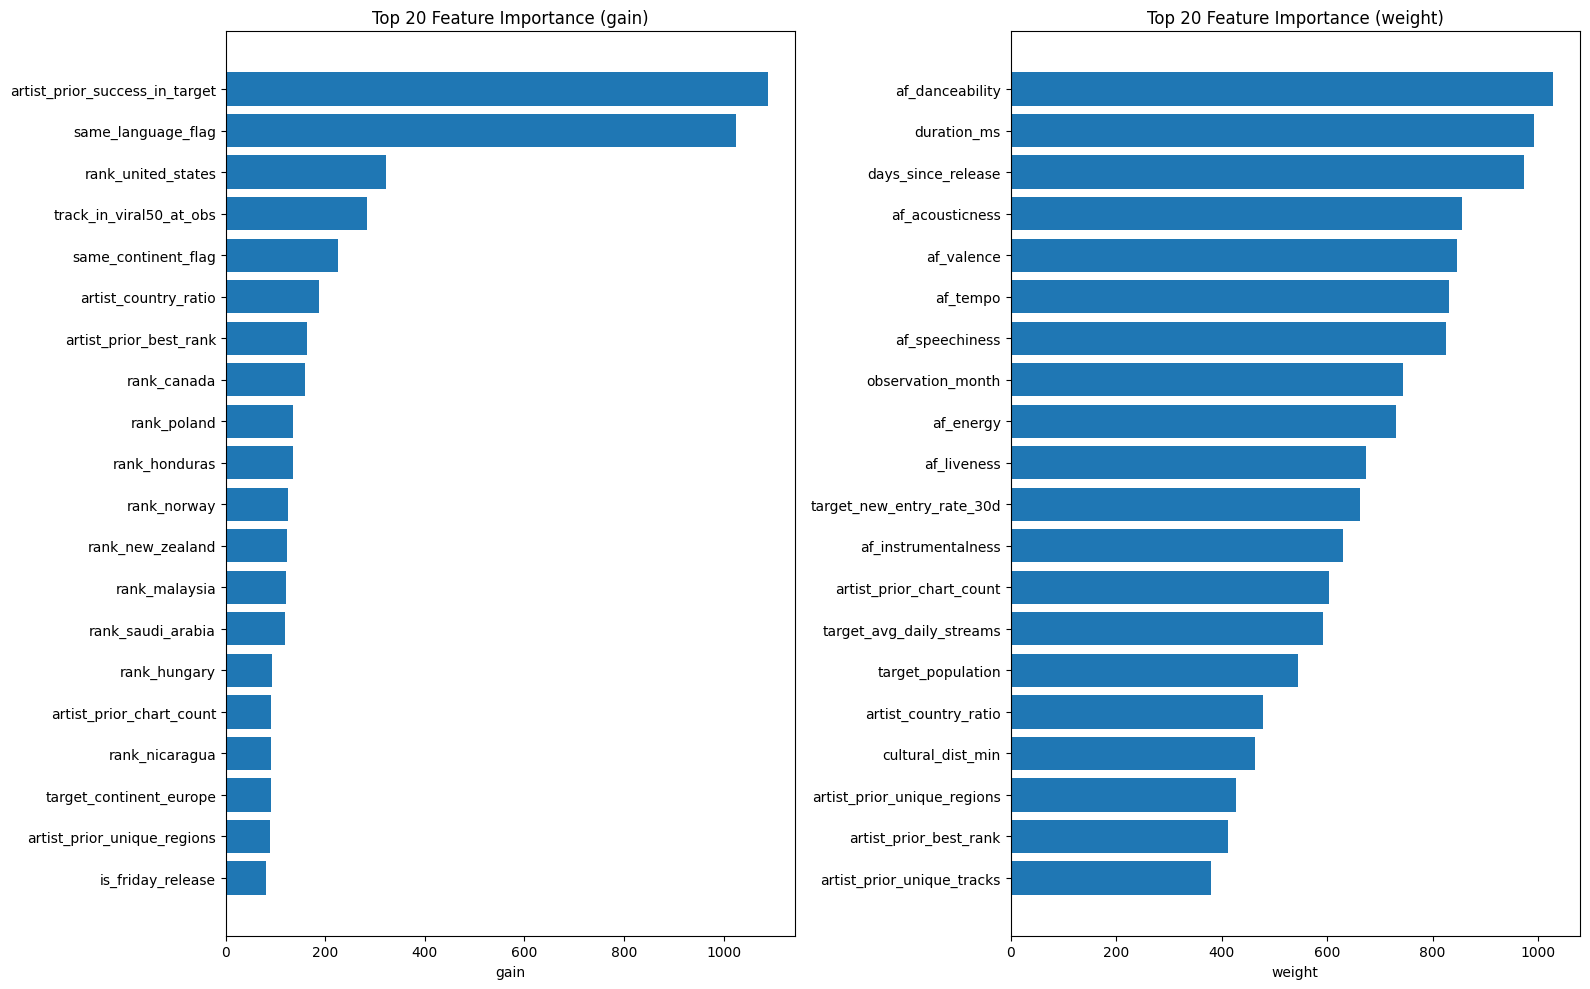

Feature category summary:


,gain,weight
category,,
current_footprint,3822.514967,5810.0
artist_history,1708.893887,2717.0
origin_target_relationship,1375.364317,1017.0
audio_track_metadata,482.796646,8600.0
target_country_priors,479.089352,2318.0
temporal,114.912781,1025.0


In [13]:
booster = model.get_booster()
importance_gain = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")

importance_df = pd.DataFrame({"feature": feature_cols})
importance_df["gain"] = importance_df["feature"].map(importance_gain).fillna(0.0)
importance_df["weight"] = importance_df["feature"].map(importance_weight).fillna(0.0)
importance_df["category"] = importance_df["feature"].map(feature_category)
importance_df = importance_df.sort_values(["gain", "weight"], ascending=[False, False]).reset_index(drop=True)

print("Top 20 features by gain:")
display(importance_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
plot_gain = importance_df.head(20).sort_values("gain")
plot_weight = importance_df.sort_values("weight", ascending=False).head(20).sort_values("weight")
axes[0].barh(plot_gain["feature"], plot_gain["gain"])
axes[0].set_title("Top 20 Feature Importance (gain)")
axes[0].set_xlabel("gain")
axes[1].barh(plot_weight["feature"], plot_weight["weight"])
axes[1].set_title("Top 20 Feature Importance (weight)")
axes[1].set_xlabel("weight")
plt.tight_layout()
plt.show()

category_summary = (
    importance_df.groupby("category")[["gain", "weight"]]
    .sum()
    .sort_values("gain", ascending=False)
)
print("Feature category summary:")
display(category_summary)


/Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computed SHAP on 63,912 rows from 1,000 sampled tracks.


,feature,mean_abs_shap,category
0,artist_prior_success_in_target,0.617315,artist_history
1,same_language_flag,0.537464,origin_target_relationship
2,artist_prior_best_rank,0.422793,artist_history
3,artist_country_ratio,0.326973,artist_history
4,same_continent_flag,0.309451,origin_target_relationship
5,af_speechiness,0.169522,audio_track_metadata
6,rank_united_states,0.160530,current_footprint
7,artist_prior_chart_count,0.138872,artist_history
8,target_new_entry_rate_30d,0.125446,target_country_priors
9,observation_year,0.124721,temporal


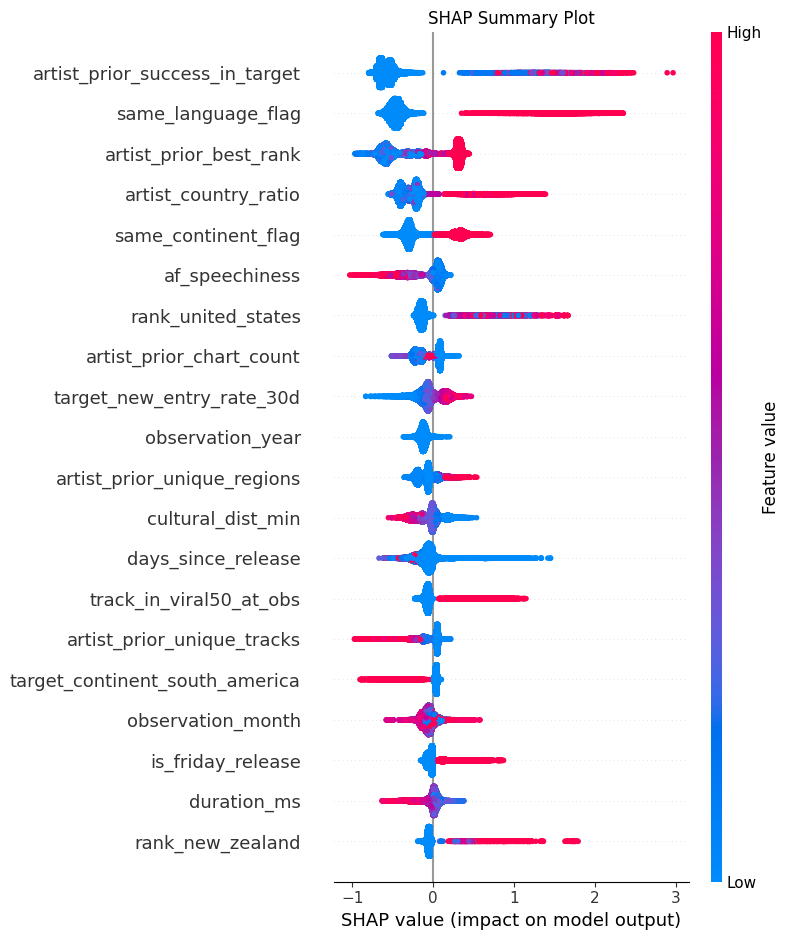

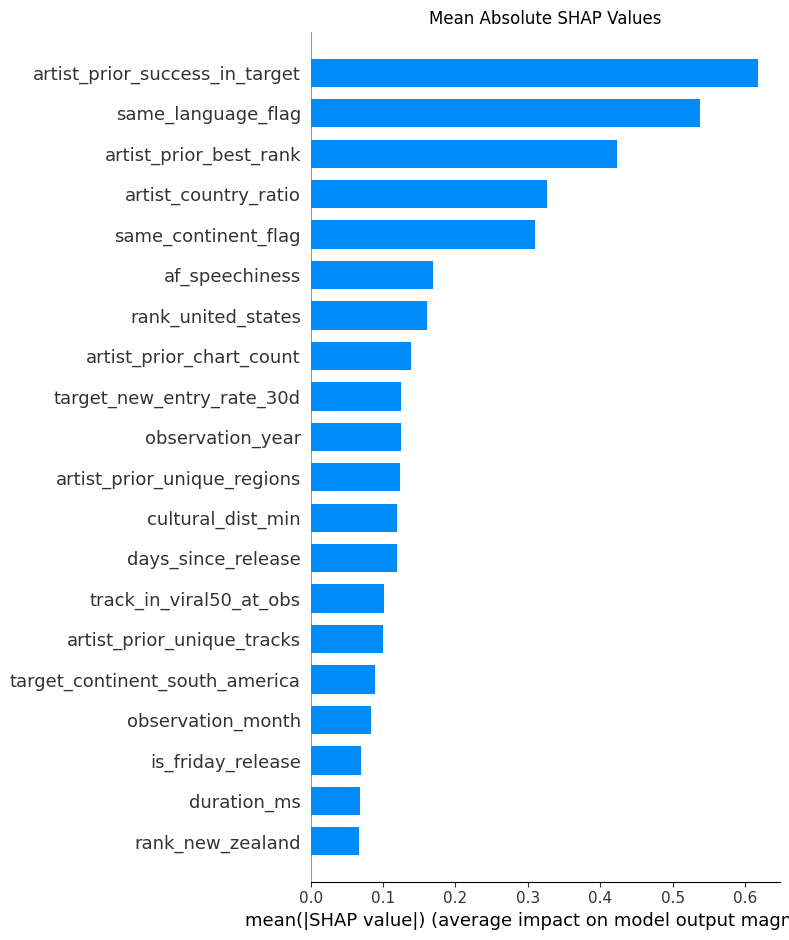

Local SHAP explanation row:


,track_id,target_country,did_enter_within_60d,days_to_entry
3635,0jdso14vaFnpRazMLEZovF,Egypt,1,17


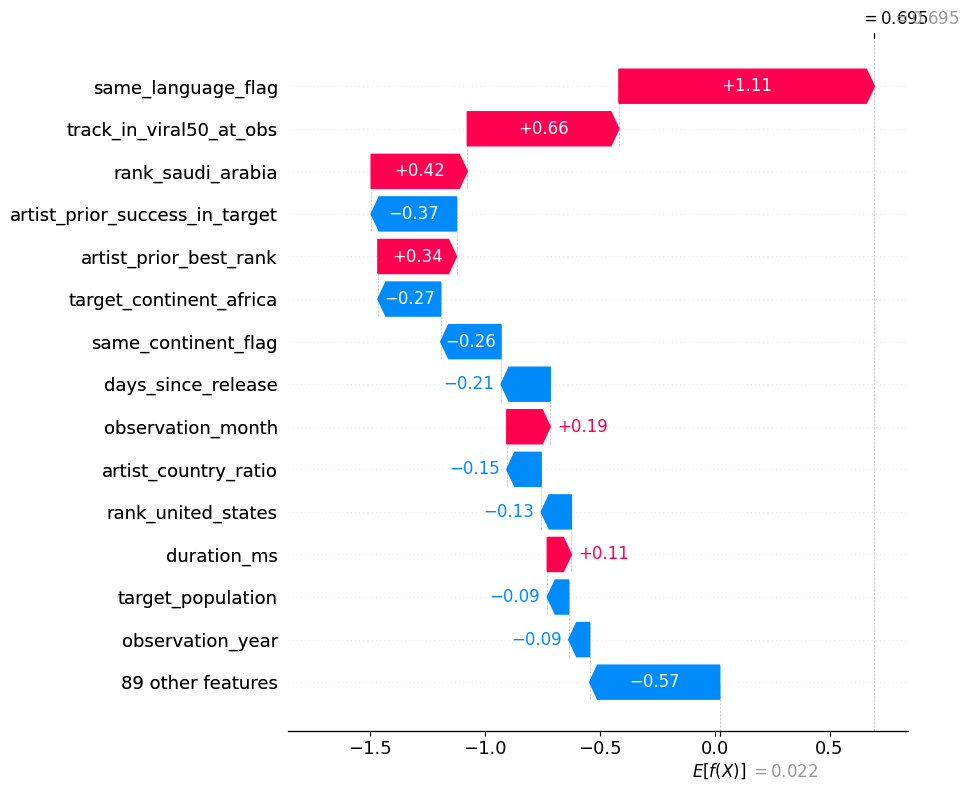

In [14]:
shap_available = False
shap_summary_df = None
shap_message = None

if RUN_SHAP:
    try:
        import shap
        shap_available = True
    except ImportError:
        shap_message = "SHAP is not installed. Run `pip install -r requirements.txt` and re-run this section."
        print(shap_message)

if shap_available:
    shap_source_df = test_df if len(test_df) <= len(val_df) else val_df
    shap_track_limit = min(SHAP_SAMPLE_TRACKS, shap_source_df["track_id"].nunique())
    shap_track_ids = (
        shap_source_df[["track_id"]]
        .drop_duplicates()
        .sort_values("track_id")
        .head(shap_track_limit)["track_id"]
        .tolist()
    )
    shap_df = shap_source_df[shap_source_df["track_id"].isin(shap_track_ids)].copy()
    X_shap = shap_df[feature_cols].fillna(fill_values)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    shap_summary_df = pd.DataFrame({
        "feature": feature_cols,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    shap_summary_df["category"] = shap_summary_df["feature"].map(feature_category)

    print(f"Computed SHAP on {len(shap_df):,} rows from {len(shap_track_ids):,} sampled tracks.")
    display(shap_summary_df.head(20))

    shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
    plt.title("SHAP Summary Plot")
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=20)
    plt.title("Mean Absolute SHAP Values")
    plt.tight_layout()
    plt.show()

    positive_candidates = shap_df[shap_df["did_enter_within_60d"] == 1]
    local_idx = positive_candidates.index[0] if not positive_candidates.empty else shap_df.index[0]
    local_pos = shap_df.index.get_loc(local_idx)
    print("Local SHAP explanation row:")
    display(shap_df.loc[[local_idx], ["track_id", "target_country", "did_enter_within_60d", "days_to_entry"]])
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values[local_pos],
        feature_names=feature_cols,
        max_display=15,
    )
    plt.show()
else:
    print("Skipping SHAP section.")


In [15]:
summary_path = EVAL_DIR / "evaluation_summary.json"
full_summary_path = EVAL_DIR / "evaluation_summary_full.json"
comparison_path = EVAL_DIR / "model_vs_baseline_comparison.parquet"
positive_analysis_path = EVAL_DIR / "positive_track_analysis.parquet"
importance_path = EVAL_DIR / "feature_importance.parquet"
val_preds_path = EVAL_DIR / "val_predictions.parquet"
test_preds_path = EVAL_DIR / "test_predictions.parquet"
track_metrics_path = EVAL_DIR / "test_track_metrics.parquet"
positive_track_metrics_path = EVAL_DIR / "test_track_metrics_positive_only.parquet"
shap_summary_path = EVAL_DIR / "shap_summary.parquet"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_summary, f, indent=2)
if RUN_FULL_SPLITS:
    with open(full_summary_path, "w", encoding="utf-8") as f:
        json.dump(evaluation_summary, f, indent=2)

con.register("comparison_df", comparison_df)
con.register("positive_analysis_df", positive_analysis_df)
con.register("importance_df", importance_df)
con.register("val_scored_df", val_predictions["xgboost"])
con.register("test_scored_df", test_predictions["xgboost"])
con.register("test_track_metrics_df", track_metric_tables["test"]["xgboost"])
con.register("test_positive_track_metrics_df", track_metric_tables["test"]["xgboost"][track_metric_tables["test"]["xgboost"]["positives"] > 0])
con.execute(f"COPY comparison_df TO '{comparison_path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")
con.execute(f"COPY positive_analysis_df TO '{positive_analysis_path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")
con.execute(f"COPY importance_df TO '{importance_path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")
con.execute(f"COPY val_scored_df TO '{val_preds_path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")
con.execute(f"COPY test_scored_df TO '{test_preds_path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")
con.execute(f"COPY test_track_metrics_df TO '{track_metrics_path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")
con.execute(f"COPY test_positive_track_metrics_df TO '{positive_track_metrics_path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")

if shap_summary_df is not None:
    con.register("shap_summary_df", shap_summary_df)
    con.execute(f"COPY shap_summary_df TO '{shap_summary_path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")
    con.unregister("shap_summary_df")

for name in [
    "comparison_df",
    "positive_analysis_df",
    "importance_df",
    "val_scored_df",
    "test_scored_df",
    "test_track_metrics_df",
    "test_positive_track_metrics_df",
]:
    con.unregister(name)

print(json.dumps(evaluation_summary, indent=2))
print(f"Saved evaluation summary to: {summary_path}")
if RUN_FULL_SPLITS:
    print(f"Saved full-run summary to: {full_summary_path}")
print(f"Saved comparison table to: {comparison_path}")
print(f"Saved positive-track analysis to: {positive_analysis_path}")
print(f"Saved feature importance to: {importance_path}")
if shap_summary_df is not None:
    print(f"Saved SHAP summary to: {shap_summary_path}")


{
  "config": {
    "top_k": 5,
    "run_mode": "sampled",
    "run_full_splits": false,
    "val_max_tracks": 10000,
    "test_max_tracks": 10000,
    "run_shap": true,
    "shap_sample_tracks": 1000
  },
  "validation": {
    "xgboost": {
      "binary": {
        "roc_auc": 0.9542507400887033,
        "average_precision": 0.23357310088500333,
        "log_loss": 0.15842729911801587
      },
      "candidate_stats": {
        "tracks": 10000,
        "positive_tracks": 811,
        "avg_candidates_per_track": 63.623,
        "avg_future_countries_per_track": 0.4038,
        "avg_future_countries_per_positive_track": 4.979038224414303
      },
      "ranking_all_tracks": {
        "tracks": 10000,
        "positive_tracks": 811,
        "precision@5": 0.027520000000000006,
        "recall@5": 0.5989744937773717,
        "hit_rate@5": 0.8310727496917386,
        "ndcg@5": 0.6390557231427955,
        "map@5": 0.5781291957802439,
        "mean_future_countries_per_track": 0.4038
      },